# Federal University of Bahia (UFBA)

## BSc in Geophysics

### Research Group: LIGA - Laboratory of Innovation in Applied Geophysics

---

**Notebook Title:** *Simultaneous inversion of velocity and density FWI using minimizer*

**Author:** *João Paulo Santos de Santana*

**Advisor:** *Prof. Peterson Nogueira Santos*

**Course:** *Undergratuate Degree*

**Line of Research:** *Seismic Imaging*

**Institution:** *Institute of Geosciences – IGEO/UFBA*

**Date:** *25/10/2025*

---

### Objectives

- This tutorial shows an example implementation of the `AbstractMinimizer` interface to execute a FWI inversion of the P-wave velocity and density simultaneously with the acoustic wave equation for variable density;

---
    
### Description

This notebook contains:

- **Brief summary of what will be done:**
- An implementation of a FWI procedure to recover the P-wave and density with the `AbstractMinimizer` interface;

- **Data or models used:**
- Marmousi true velocity model loaded from a binary file (`data/marmo_vp_nx170nz80dx25dz25.bin`);

- **Applied methodology:**
- TODO;
<!-- - Seismic data were generated using the true velocity model with a 2D acoustic wave equation operator (`AcousticWave2D`) from Pylops
- Ricker wavelets with varying peak frequencies (from 5 Hz to `f_max` Hz)
- A Wiener filter is applied to filter observed data -->

In this tutorial we will implement a FWI procedure to estimate the P-wave velocity profile, $v_P$, and density, $\rho$, using the `AbstractMinimizer`, which is an interface between Devito and SciPy's `minimize()` function.

We will make an example subclass of the `AbstractMinimizer` to implement the FWI.

# 1. Setup

The code in this section is the basic Devito setup to load the model, create the geometry and precompute the observed data. The readers who feel comfortable with these procedures can safely skip to the next section.

## 1.1. Required libraries

In [1]:
import numpy as np
from pathlib import Path
from examples.seismic.inversion.minimizer import AbstractMinimizer
from extra_plotting import plot_density
from examples.seismic.acoustic.variable_density.wavesolver import VariableDensityAcousticWaveSolver
from examples.seismic import plot_velocity, plot_image, plot_shotrecord
from examples.seismic import Model, AcquisitionGeometry, setup_geometry, Receiver
from devito import *

configuration['log-level'] = 'WARNING'

mpi4py is not available. You must install it


In [2]:
BASE_DIR = Path.cwd()
path = BASE_DIR.parent / "Petrophysics"/"vp_rho_smeaheia.npz"

## Forward modeling

The propagation of seismic waves in heterogeneous, isotropic, elastic earth media can be expressed by the acoustic equation:

\begin{equation}
m\dfrac{\partial^2 u}{\partial t^2} - \rho \nabla \cdot \left( \frac{1}{\rho} u \right) + \eta \frac{\partial u}{\partial t} = \mathbf{f},
\end{equation}


where $u = u(x, z,t)$ is the pressure field, $m = vp^{-2}(x, z)$ is the squared slowness and $\mathbf{f} = \mathbf{f}(x, z,t)$ is the source term and $\eta = \eta(x,z)$ is a damp term

## Adjoint modeling 

\begin{equation} \tag{2}
m\dfrac{\partial^2 v}{\partial t^2} - \nabla  \cdot   \left( \frac{1}{\rho} \nabla (\rho v)  \right) -  \frac{\partial v}{\partial t} \eta = \mathbf{f},
\end{equation} 

where $v = v(x,z,t)$ is the adjoint field


## 1.2. Model

We will first create our velocity model. There are some functions defined in the block below to create our true model and a smoothed version of it, which will serve as our initial model.

In [3]:
def load_model(file_name: str):
    nx, nz = 98, 100
    dx = dz = 25

    vp = np.load(file_name)['vp']
    rho = np.load(file_name)['rho'] 

    origin = (0,0)
    shape = (nx, nz)
    spacing = (dx, dz)
    space_order = 8
    nbl = 50

    model = Model(
        origin=origin,
        spacing=spacing,
        shape=shape,
        space_order=space_order,
        vp=vp,
        b=1.0/rho,
        nbl=nbl,
        bcs='damp',
        staggered=NODE
    )
    
    return model

def copy_model(model: Model):
    nbl = model.nbl
    slc = [
        slice(nbl,-nbl),
        slice(nbl,-nbl)
    ]

    model2 = Model(
        origin=model.origin,
        spacing=model.spacing,
        shape=model.shape,
        space_order=model.space_order,
        grid=model.grid,
        vp=model.vp.data[slc],
        b=model.b.data[slc], 
        nbl=model.nbl,
        bcs='damp',
        staggered=NODE
    )

    model2.vp.data[:] = model.vp.data[:]
    model2.b.data[:] = model.b.data[:]  

    return model2

def smooth_model(model: Model, std: float = 1):
    models = copy_model(model)
    gaussian_smooth(models.vp, std)
    gaussian_smooth(models.b, std) 

    return models

In [4]:
model = load_model(path)
model0 = smooth_model(model, 5)
mask = model.vp.data <= 1.5
model0.vp.data[:] = model0.vp.data * (1 - mask) + model.vp.data * mask
# rho0 = 0.31 * (model0.vp.data * 1000.) ** 0.25
# rho_true = 0.31 * (model.vp.data * 1000.) ** 0.25
rho0 = 1./model0.b.data; rho_true=1./model.b.data
rho0[:] = rho0 * (1 - mask) + rho_true * mask
model0.b.data[:] = 1.0 / rho0

Now that we created our models, let's see what they look like.

True model of vp:


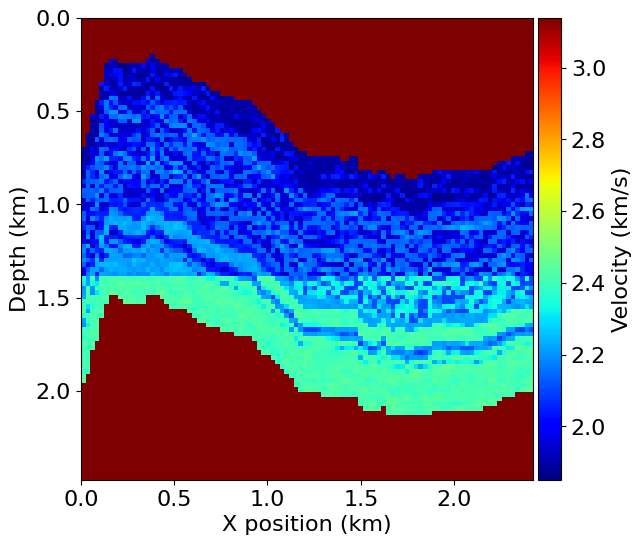

Initial model of vp:


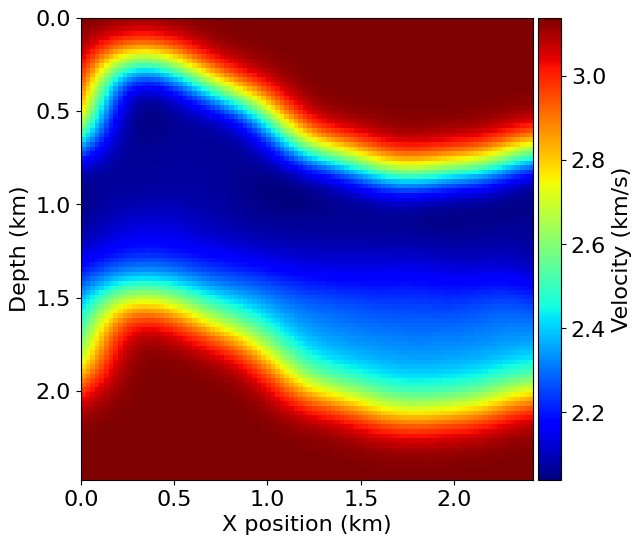

True model of rho:


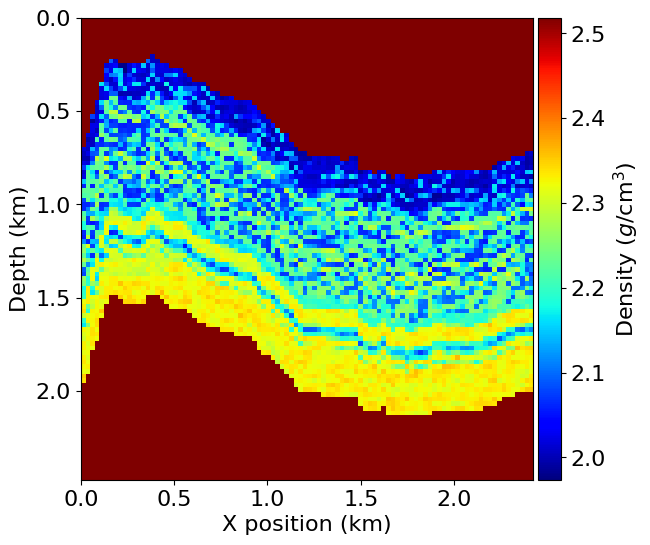

Initial model of rho:


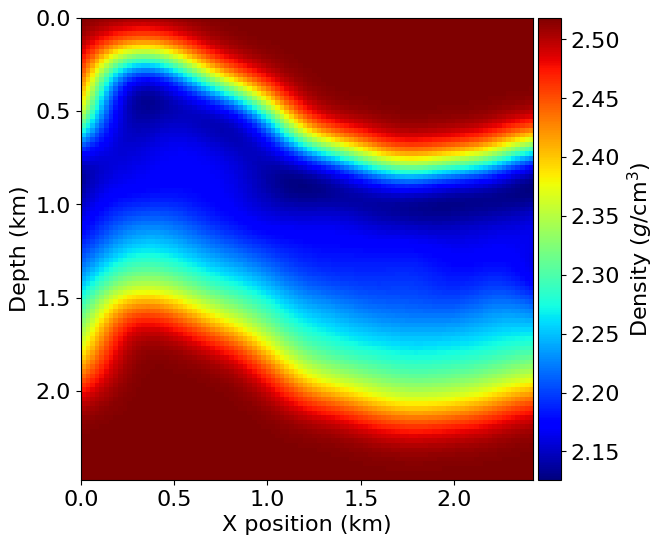

In [5]:
print('True model of vp:')
plot_velocity(model)
print('Initial model of vp:')
plot_velocity(model0)
print('True model of rho:')
plot_density(model)
print('Initial model of rho:')
plot_density(model0)

## 1.3. Geometry

Now that we created our model, we must define our aquisition geometry.

In [6]:
tn = 3000
f0 = 0.020

In [7]:
# nsrc = 20
# nrec = model.shape[0]

# src_positions = np.zeros((nsrc, 2))
# src_positions[:, 0] = np.linspace(0, model.domain_size[0], num=nsrc)
# src_positions[:, 1] = 25

# rec_positions = np.zeros((nrec, 2))
# rec_positions[:, 0] = np.linspace(0, model.domain_size[0], num=nrec)
# rec_positions[:, 1] = 0

In [8]:
nsrc = 20
nrec = model.shape[0]
par = {
    'nx': 98,   'dx': 25,     'ox': 0.,
    'nz': 100,  'dz': 25,     'oz': 0.,
    'ns': 20,   'ds': 175,    'sz': 0.,
    'nr': 98,   'dr': 25,     'rz': 0.,
    'nt': 3000, 'dt': 0.002,   't0': 0.,
    'nw': 5,   'freq': 20}

shape = (par['nx'], par['nz'])
spacing = (par['dx'], par['dz'])
origin = (par['ox'], par['oz'])
# Setting receivers positions
rec_positions = np.zeros((par['nr'], 2))
rec_positions[:, 0] = np.arange(par['nr']) * par['dr'] # receivers positions
rec_positions[:, 1] = par['rz']

# Setting source positions
model_domain_size = ((shape[0]-1)*spacing[0], (shape[1]-1)*spacing[1])
src_positions = np.zeros((par['ns'], 2))
src_positions[:,0] = np.linspace(0., model_domain_size[0], num=par['ns'])
src_positions[:,1] = origin[1] + spacing[1] * 2

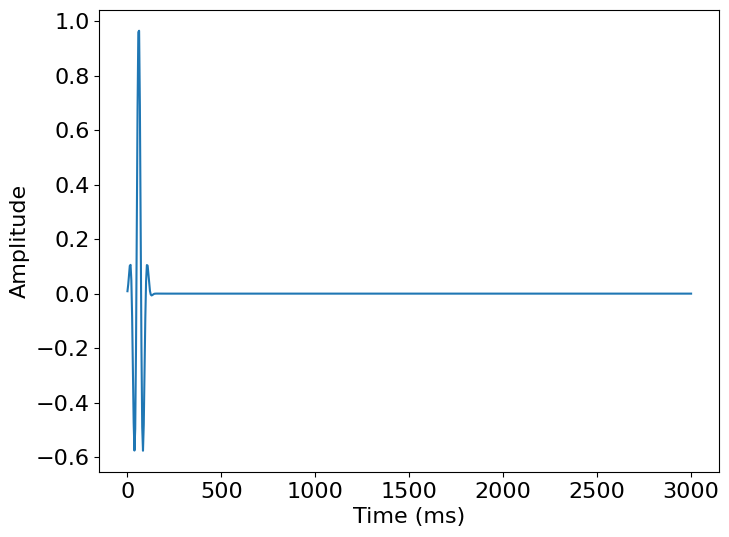

In [9]:
geometry = AcquisitionGeometry(model, rec_positions, np.zeros((1,2)), 0, tn, f0=f0, src_type='Ricker')
geometry.src.show()

Let's see our geometry over the true model.

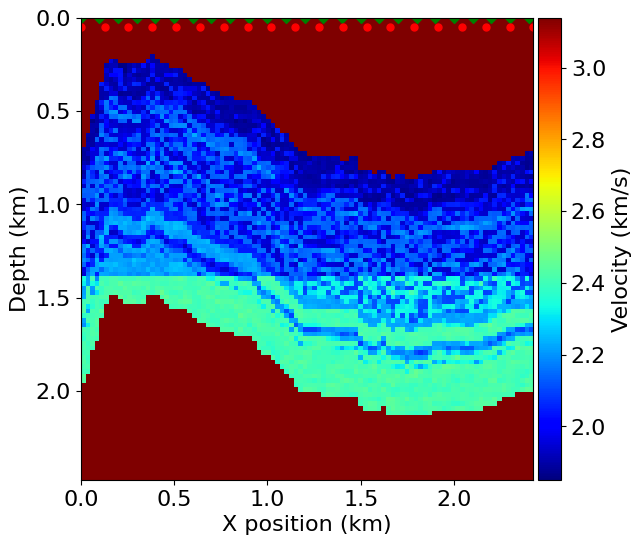

In [10]:
plot_velocity(model, src_positions, rec_positions[::4])

## 1.4. Wave equation solver

In [11]:
solver =  VariableDensityAcousticWaveSolver(model, geometry, space_order=model.space_order)

## 1.5. Precomputing shot data

In [12]:
dobs_list = []

for i in range(nsrc):
    geometry.src_positions[0, :] = src_positions[i, :]

    rec, _, _ = solver.forward(model=model)

    dobs_list.append(rec)

Quick test to check if the residual will be computed correclty.

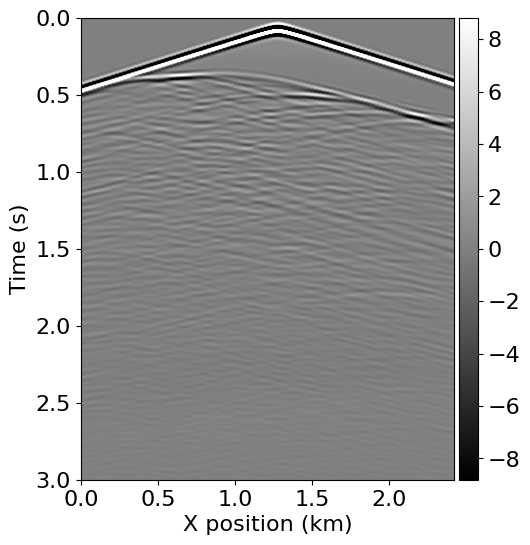

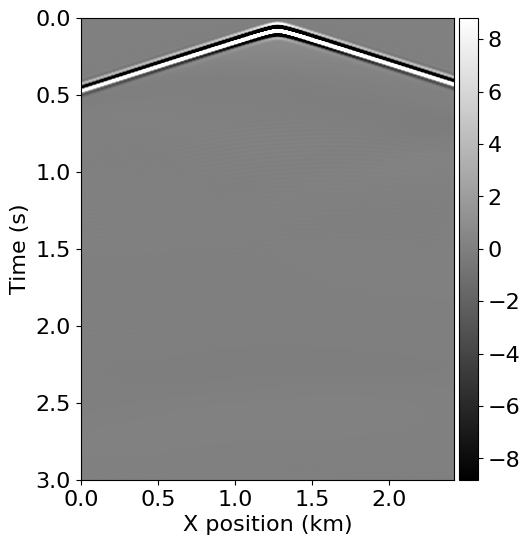

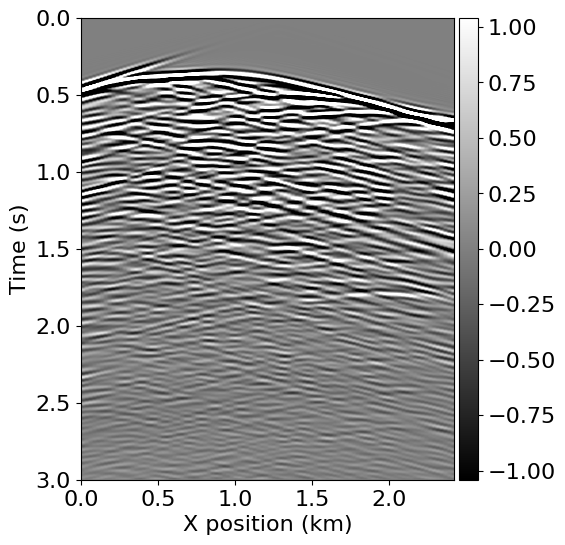

In [13]:
geometry.src_positions[0, :] = src_positions[nsrc//2, :]
rec, _, _ = solver.forward(model=model)
rec0, _, _ = solver.forward(model=model0)

plot_shotrecord(rec.data, model, geometry.t0, geometry.tn)
plot_shotrecord(rec0.data, model, geometry.t0, geometry.tn)
plot_shotrecord(rec.data - rec0.data, model, geometry.t0, geometry.tn)

# 2. Inversion

## 2.1. Subclassing `AbstractMinimizer`

Now that we are done doing the usual Devito setup, we are going to implement a subclass of the `AbstractMinimizer`. We will put the entire implentation here in this notebook for the sake of readability, but it would be preferred to put it in a separate `.py` file and import it into a notebook (check out the implementation on [example/example_minimizer.py](./example/example_minimizer.py) to see how this could be done).

Without further ado, let's write our subclass. We will call it `ExampleMinimizer`.

In [14]:
from examples.seismic.inversion.minimizer import AbstractMinimizer

class ExampleMinimizer(AbstractMinimizer):
    def __init__(self,  geometry: AcquisitionGeometry, src_positions: np.ndarray, dobs_list: list):
        super().__init__(['vp','b'])
        self.geometry = geometry
        self.dobs_list = dobs_list
        self.src_positions = src_positions

    def on_procedure_initialization(self, model0):
        pass
    
    def loss_grad(self, model0):
        pass

In the block above, we've defined our subclass constructor and have called the superclass constructor (the `super().__init__` method) passing a list with the name of the parameters of our model as its argument.

This list is used by `AbstractMinimizer` to convert the model from the SciPy's `minimize` format to the Devito SeismicModel and vice-versa. This list is also used to convert the gradients computed in Devito, which are `Function`s, to a format `minimize` will accept.

This class also receives the acqusition geometry, the list of source positions and a list with the precomputed observed data.

Next, we will override the `on_procedure_initialization` method. This method is called once by the `AbstractMinimizer` just before it starts the inversion procedure with `minimize`. We will use this method to create our wavesolver.

In [15]:
def on_procedure_initialization(self, model0):
    self.solver = VariableDensityAcousticWaveSolver(
        self.model_manager.reference_model, 
        self.geometry, 
        space_order=model0.space_order
    )


ExampleMinimizer.on_procedure_initialization = on_procedure_initialization

This method receives as parameter the `model0`, which is the initial model passed to the `start` method. We will cover this method in more detail later.

Note that we initialized the wave solver with `model_manager.reference_model`. This is a model created automatically by the `AbstractMinimizer` based on the initial model and the value range of its parameters (it actually defers the creation to another class called `ModelManager`, which handles the actual conversion between the different model representations). This model contains parameters with the limiting values of the provided range. Its preferred to use it as a reference model for the wave solver because the parameter values may affect the computation of $\Delta t$.


Lastly, we will implement the `loss_grad` method. This is where we will compute the gradient and loss function value for the current model.

## Gradient Calculation

As the objective is to simultaneously invert for velocity ($v$) and density ($\rho$), the gradients of the objective function $J$ are computed for each parameter. The gradient with respect to velocity is given by:

\begin{equation}
\nabla_v J = - \int_0^T \frac{\partial^2 P}{\partial t^2} \, q \, dt
\end{equation}

And the gradient with respect to density is given by:

\begin{equation}
\nabla_\rho J = \int_0^T \left( \frac{1}{\rho^2} \nabla \rho \cdot \nabla P - \frac{1}{\rho} \nabla^2 P \right) q \, dt
\end{equation}

where $P = P(x, z, t)$ is the forward pressure field and $q = q(x, z, t)$ is the adjoint field.

In [16]:
def loss_grad(self, model0):
    grid = self.model_manager.reference_model.grid
    solver: VariableDensityAcousticWaveSolver = self.solver
    geometry = solver.geometry
    space_order = self.model_manager.reference_model.space_order
    src_positions = self.src_positions

    grad = {
        
        'vp': Function(name="gradfull_vp", grid=grid, space_order=space_order, staggered=NODE),

        #'illum_vp': Function(name="illumfull_vp", grid=grid, space_order=space_order, staggered=NODE),
        

        'b': Function(name="gradfull_b", grid=grid, space_order=space_order, staggered=NODE),
        
        #'illum_b': Function(name="illumfull_b", grid=grid, space_order=space_order, staggered=NODE)
    }
    
    grad_vp = grad['vp']   
    #illum_vp = grad['illum_vp']
    grad_b = grad['b'] 
    #illum_b = grad['illum_b']

    loss = 0 

    for isrc in range(src_positions.shape[0]):
        residual = Receiver(name='residual', grid=grid,
                            time_range=geometry.time_axis, 
                            coordinates=geometry.rec_positions)
        
        #dillum_vp = Function(name="dillum_vp", grid=grid, space_order=space_order, staggered=NODE)
        
       
        #dillum_b = Function(name="dillum_b", grid=grid, space_order=space_order, staggered=NODE)
        
        geometry.src_positions[0, :] = src_positions[isrc, :]

        dobs = self.dobs_list[isrc]
        dsyn, u0, _ = solver.forward(model=model0, save=True)

        residual.data[:] = dsyn.data - dobs.data
        
        loss += .5*norm(residual)**2
        
        (dgrad_m, dgrad_b), _ = solver.gradient(rec=residual, u=u0, model=model0)

        #Operator(Eq(dillum_vp, dillum_vp + (-2/model0.vp**3 * u0.dt2)**2))(dt=solver.dt)
        
        #perator(Eq(dillum_b, dillum_b + u0.grad().dot(u0.grad())))(dt=solver.dt)
        
        Operator(Eq(grad_vp, grad_vp + dgrad_m))() 
        #Operator(Eq(illum_vp, illum_vp + dillum_vp))()
        
        Operator(Eq(grad_b, grad_b + dgrad_b))()
        #Operator(Eq(illum_b, illum_b + dillum_b))()
    

    Operator(Eq(grad_vp, -2/model0.vp**3 * grad_vp))()
    
    return loss, grad


ExampleMinimizer.loss_grad = loss_grad

The first five lines are just creating shorthands variables to make the subsequent code cleaner. After that, we create a dictionary to store the gradients:

```python
grad = {
    'vp': Function(name="gradfull", grid=grid, space_order=space_order, staggered=NODE),
    'illum_vp': Function(name="illumfull", grid=grid, space_order=space_order, staggered=NODE),
}
```
This is how the `AbstractMinimizer` expects the gradients that are returned by `loss_grad` to be. The keys in of the dictionary must match the list of properties sent to the `AbstractMinimizer` constructor and it has to contain a gradient for each property.

Additionally, you can put extra data on this dictionary to be passed to subsequent filters on the gradient post-processing pipeline (more on this later). These will be usualy ignored if unused, but it can conflict with other filters.

After that, we loop through the source positions, compute the gradients for each shot, sum them in the total gradient (`grad_vp`) and return a tuple with the total loss and the gradient dictionary. For a more detailed exposition of this process, see tutorials 03 and 13.

With this, we can finally create an instance of `ExampleMinimizer`.

In [17]:
minimizer = ExampleMinimizer(geometry, src_positions, dobs_list)

## 2.2. Pipelines

Before building a pipeline to our inversion procedure, below is an explanation of how they works.

The `AbstractMinimizer` pipelines are lists of functions that act on the model or the gradient, making modifications on them before sending to or after receiving from `minimize`. They are a list of functions with the format
```python
def example_model_filter(model: Model):
    ... # Make some changes on model
    return modified_model
```
or
```python
def example_gradient_filter(grad: dict):
    ... # Make some changes on grad
    return modified_grad
```
These functions are called filters and provides a way to dynamically modify the inversion procedure behavior without having to modify the class implementation. This is useful to, for example, test different methods for preconditioning the gradient after the implementation is already done.

The functions added to a pipeline are called in the order they are added to the list, with the output of a function being the input of the next in the line. For example, if we have
```python
minimizer.grad_postprocess_pipeline = [
    filter1, filter2, filter3
]
```
Then, after receiving the gradient from `loss_grad`, the following will happen
```python
# Simplified version of the code executed by the AbstractMinimizer
loss, grad = loss_grad(...)
grad1 = filter1(grad)
grad2 = filter2(grad1)
grad3 = filter3(grad2)

grad_final = convert_grad(grad3) # Converts the dictionary to a ndarray

return loss, grad_final # Send to minimize
```

There are 4 pipelines in the `AbstractMinimizer` class:

- `model_ndarray_preprocess_pipeline`: Functions that act over the `numpy.ndarray` representation of the model. They are called right after the model is received from the `minimize` and reshaped into a convenient format;

- `model_preprocess_pipeline`: Functions that act over the `SeismicModel` or `ElasticModel` representation of a model. They are called after the previous pipeline is executed and model is converted from a `numpy.ndarray` into this representation;

- `grad_postprocess_pipeline`: Functions that act over a gradient dictionary. They are called right after the `loss_grad` returns its result;

- `grad_ndarray_postprocess_pipeline`: Functions that act over the `numpy.ndarray` representation of the model. They are called after the previous pipeline is executed and the gradient is converted to the same shape as the model's `numpy.ndarray` representation.

For our procedure, we are going to send a normalized model to `minimize`, so we will use a filter to remap its values to the original range so we can use it in our wave solver. We will also add a filter to clip the model values into a speciefied range, wich is made available as a method by the `AbstractMinimizer`.

Regarding the gradient, we will implement a custom illumination compensation filter and couple of predefined filters.

In [18]:
from examples.seismic.inversion.filter.model_filters import ModelNormalizationFilter

def debug_model(model):
    plot_velocity(model)
    return model

minimizer.model_ndarray_preprocess_pipeline = [
    
    ModelNormalizationFilter(
        [
            (mmin(model.vp), mmax(model.vp)), 
            (mmin(model.b), mmax(model.b))   
        ], 
        denormalize_mode=True
    ),
    
    minimizer.clip_model_values_filter,

]

In [19]:
from examples.seismic.inversion.filter.grad_filters import MaskFilter
from examples.seismic.inversion.filter.grad_filters import FirstDerivativeNormalizationFilter

#def compensate_illumination_filter(grad): # You can also define filters on the fly
    #gradvp = grad['vp']
    #gradb = grad['b'] 
    #illum_vp = grad['illum_vp']
    #illum_b = grad['illum_b']

    #Operator(Eq(gradvp, gradvp / (illum_vp + 1e-9)))()
    #Operator(Eq(gradb, gradb / (illum_b + 1e-9)))() 
    
    
    #modified_grad = {
     #   'vp': gradvp,
      #  'b': gradb
   # }
   # return modified_grad
   

def debug_grad(grad):
    slc = [
        slice(model.nbl, -model.nbl),
        slice(model.nbl, -model.nbl)
    ]
    plot_image(grad['vp'].data[slc])
    plot_image(grad['b'].data[slc])
    return grad

minimizer.grad_postprocess_pipeline = [
    #compensate_illumination_filter,
    # This filter applies the speciefied mask to the gradient.
    MaskFilter(model.vp.data[:] > 1.5), 
    # This filter normalizes the gradients by the maximum of the first gradient.
    FirstDerivativeNormalizationFilter(['vp','b'], [slice(model.nbl, -model.nbl)]*2)
]

## 2.3. FWI procedure

At long last, we can run our FWI procedure. This is done with the `start` method. It accepts 4 parameters:

- `model0`: This is the initial model;
- `params_range`: A list of tuples with the minimum and maximum value of each physical property, in the same order as the list of names specified in the constructor. That is, if the list of parameters is `['vp', 'b']`, the first element of this list will be `(vp_min, vp_max)` and the second will be `(b_min, b_max)`;
- `maxiter`: The maximum number of iterations;
- `callback`: A function called at the end of each iteration. It receives the model from `minimize` and an instance of the minimizer object as parameters;

In [20]:
# Defining parameters
params_range = [
    (mmin(model.vp), mmax(model.vp)),
    (mmin(model.b), mmax(model.b)),
]

maxiter = 50

def fwi_callback(x, minimizer):
    print(f'Finished iteration {minimizer.iteration}')
    print(f'\tLoss: {minimizer.loss_history[-1]}')

We will normalize the model before sending it to the minimizer. That is why we have included the `ModelNormalization` filter with the denormalization mode in the `model_preprocess_pipeline`.

In [21]:
model0_normalized = copy_model(model0)
model0_normalized.vp.data[:] = (model0.vp.data[:] - params_range[0][0])/(params_range[0][1] - params_range[0][0])
model0_normalized.b.data[:] = (model0.b.data[:] - params_range[1][0])/(params_range[1][1] - params_range[1][0])

In [22]:
# This will execute the inversion procedure
minimizer.start(model0_normalized, params_range, maxiter, fwi_callback)

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =        19600     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  4.59574D+05    |proj g|=  1.00000D+00


 This problem is unconstrained.



Finished iteration 1
	Loss: 397043.91754605656
At iterate    1    f=  3.97044D+05    |proj g|=  2.15400D+00

Finished iteration 2
	Loss: 351058.6157741677
At iterate    2    f=  3.51059D+05    |proj g|=  2.11042D+00

Finished iteration 3
	Loss: 307141.58681639074
At iterate    3    f=  3.07142D+05    |proj g|=  2.38007D+00

Finished iteration 4
	Loss: 283387.0591320781
At iterate    4    f=  2.83387D+05    |proj g|=  4.26149D+00

Finished iteration 5
	Loss: 283387.0464625289
At iterate    5    f=  2.83387D+05    |proj g|=  4.26149D+00
  ys=-1.739E-14  -gs= 3.883E-07 BFGS update SKIPPED



 Bad direction in the line search;
   refresh the lbfgs memory and restart the iteration.



Finished iteration 6
	Loss: 283054.9832219059
At iterate    6    f=  2.83055D+05    |proj g|=  4.27873D+00

Finished iteration 7
	Loss: 281773.73572290514
At iterate    7    f=  2.81774D+05    |proj g|=  6.45651D+00

Finished iteration 8
	Loss: 281773.7271636438
At iterate    8    f=  2.81774D+05    |proj g|=  6.45651D+00

Finished iteration 9
	Loss: 281735.91278064216
At iterate    9    f=  2.81736D+05    |proj g|=  6.45319D+00

Finished iteration 10
	Loss: 281735.89214318094
At iterate   10    f=  2.81736D+05    |proj g|=  6.45319D+00
  ys=-2.830E-13  -gs= 2.007E-06 BFGS update SKIPPED



 Bad direction in the line search;
   refresh the lbfgs memory and restart the iteration.



Finished iteration 11
	Loss: 281717.7730272439
At iterate   11    f=  2.81718D+05    |proj g|=  6.45275D+00

Finished iteration 12
	Loss: 264597.06111364684
At iterate   12    f=  2.64597D+05    |proj g|=  5.72635D+00

Finished iteration 13
	Loss: 264597.0559329032
At iterate   13    f=  2.64597D+05    |proj g|=  5.72635D+00



 Bad direction in the line search;
   refresh the lbfgs memory and restart the iteration.



Finished iteration 14
	Loss: 264597.0559329032
At iterate   14    f=  2.64597D+05    |proj g|=  5.72635D+00

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
19600     14    173      4     2     0   5.726D+00   2.646D+05
  F =   264597.05593290320     

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH             



   evaluations in the last line search.  Termination
   may possibly be caused by a bad search direction.


Once the procedure has finished, we can access the inverted model.

In [23]:

model_inv = minimizer.model_manager.ndarray_to_model(
    ModelNormalizationFilter(params_range).denormalization(
        minimizer.result.x.reshape(minimizer.model_manager.params_shape),
    )
)

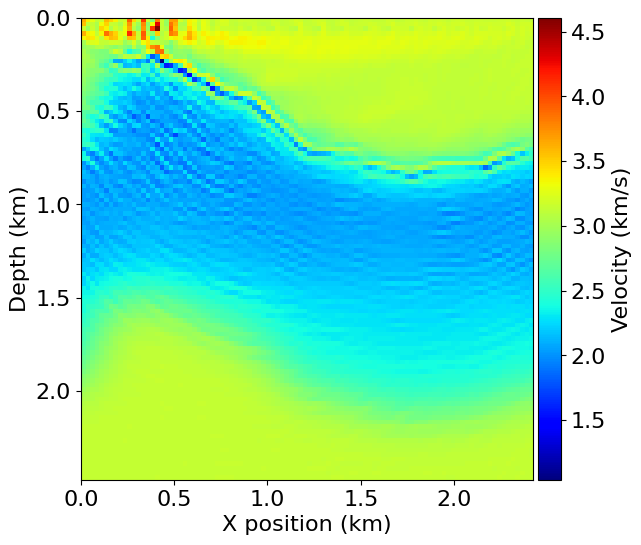

In [24]:
plot_velocity(model_inv)

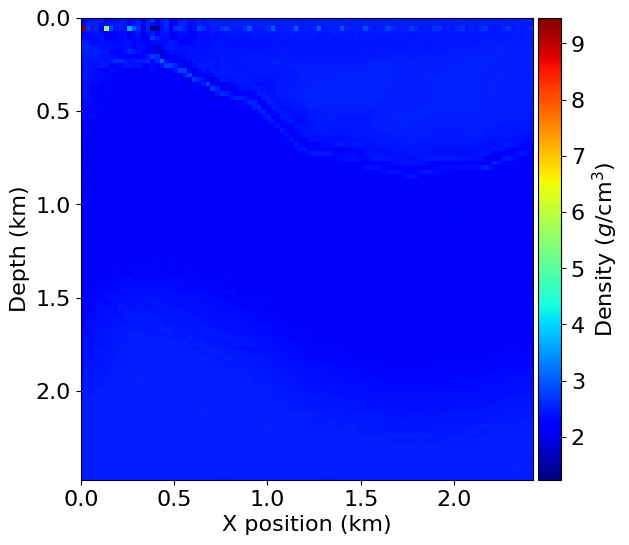

In [25]:
plot_density(model_inv)

We can access the loss function values at each iteration with the `loss_history` attribute.

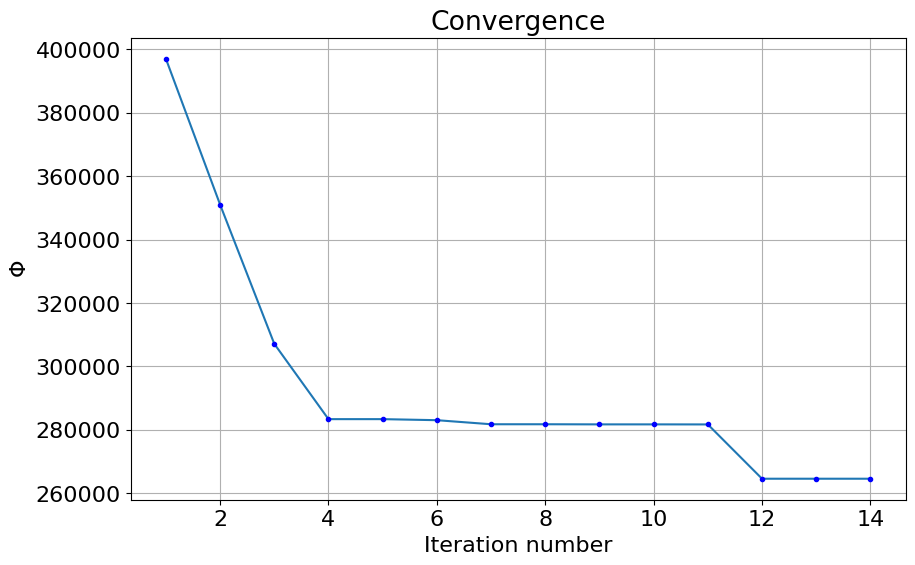

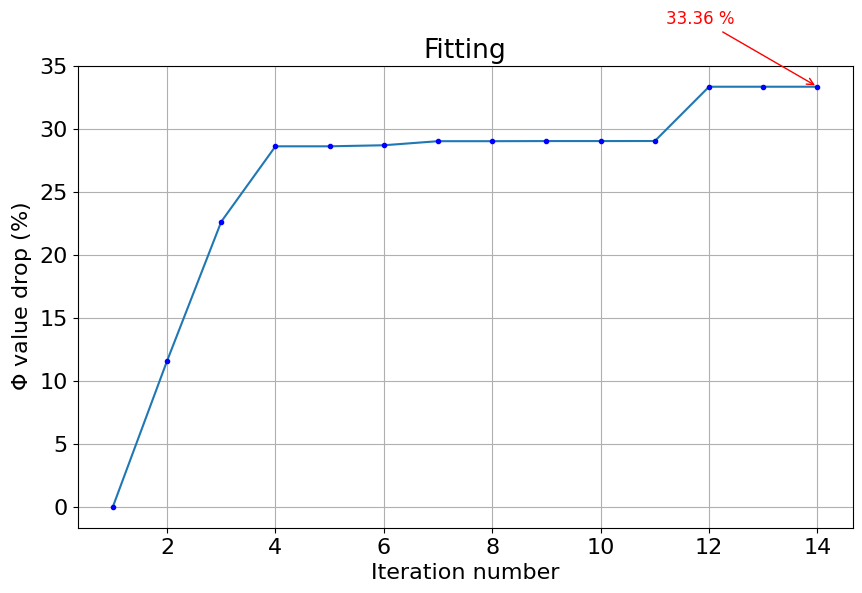

In [26]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(minimizer.loss_history)) + 1

plt.figure(figsize=(10, 6)) 
plt.ylabel('$\\Phi$')
plt.plot(x, minimizer.loss_history)
plt.plot(x, minimizer.loss_history, '.b')
plt.grid()
plt.xlabel('Iteration number')
plt.title('Convergence')
plt.show()

plt.figure(figsize=(10, 6)) 

loss_drop_percent = (1 - np.array(minimizer.loss_history) / minimizer.loss_history[0]) * 100
val = loss_drop_percent[-1]
maxiter = x[-1]  

plt.ylabel('$\\Phi$ value drop (%)')
plt.plot(x, loss_drop_percent)
plt.plot(x, loss_drop_percent, '.b')
plt.grid()
plt.xlabel('Iteration number')
plt.title('Fitting')

plt.annotate(
    f'{val:.2f} %', 
    xy=(maxiter, val), 
    xytext=(maxiter*0.8, val + 5),  
    arrowprops={'arrowstyle': '->', 'color': 'red'},
    fontsize=12,
    color='red'
)

plt.show()
